In [5]:
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter
from pymoo.core.problem import Problem
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.termination import get_termination

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FuncFormatter

import pandas as pd
import numpy as np
import pickle
import json
from datetime import datetime

In [4]:
class UnifiedBuildingCalculator:
    """
    统一计算类：确保 LCC 和 LCCE 基于完全相同的能耗预测值
    【修正】特征工程已对齐 type-fix 版本：整数键 u_value_map + 条件参数激活 + _eff 列替换
    """
    def __init__(self):
        # 1. 加载能耗模型（type-fix 版本）
        with open("s_xgb_energy_final.pkl", 'rb') as f:
            self.energy_model = pickle.load(f)

        # 2. 加载 sDA 模型（type-fix 版本）
        with open("s_xgb_sDA_final.pkl", 'rb') as f:
            self.udi_model = pickle.load(f)

        # 3. 材料参数
        self.material_props = {
            'thickness': {1: 50, 2: 5, 3: 5},           # mm
            'ce_factor': {1: 385, 2: 56231, 3: 16400},    # kgCO2/m³
            'density': {1: 2400, 2: 2770, 3: 8000},      # kg/m³
            'distance': {1: 40, 2: 500, 3: 500},          # km
            'replacement': {1: 1, 2: 2, 3: 2}
        }

        # 4. 全局常量
        self.room_area = 90
        self.operation_factor = 0.3748 * 50   # 运营阶段系数
        self.electricity_price = 0.8262        # 电价

        # 5. 获取模型期望的特征列（关键：type-fix 版本列名与顺序）
        if hasattr(self.energy_model, 'feature_names_in_'):
            self.expected_columns = list(self.energy_model.feature_names_in_)
            print("能耗模型期望的特征列：", self.expected_columns)
        else:
            # 【修正】fallback 列名与顺序已与 type-fix 训练代码严格对齐
            self.expected_columns = [
                'hor_depth', 'int', 'depth', 'distance', 'wwr',
                'hori_rot_eff', 'ver_rot_eff',
                'glazing_u_value', 'thermal_load_index', 'wwr_ver_rot', 'wwr_int', 'shade_balance',
                'type_1', 'type_2', 'type_3',
                'mat_1', 'mat_2', 'mat_3',
                'win_1', 'win_2', 'win_3', 'win_4'
            ]
            print("⚠️ 使用 fallback 列名（type-fix 顺序）")

        # 检查 sDA 模型期望列
        if hasattr(self.udi_model, 'feature_names_in_'):
            udi_cols = list(self.udi_model.feature_names_in_)
            if udi_cols != self.expected_columns:
                print("⚠️ 警告：sDA 模型期望列与能耗模型不一致！")
                print("sDA 模型列：", udi_cols)

    def _preprocess(self, X):
        """
        统一的特征预处理：与 XGBoost type-fix 训练代码完全一致
        输入：10维原始参数（含 hori_rot/ver_rot）
        输出：22维 type-fix 特征（含 hori_rot_eff/ver_rot_eff）
        """
        columns = ['hor_depth', 'type', 'mat', 'int', 'hori_rot',
                   'ver_rot', 'depth', 'distance', 'wwr', 'win']
        df = pd.DataFrame(X, columns=columns)

        # 分类变量四舍五入为整数（NSGA 输出为浮点，需离散化）
        categorical_cols = ['type', 'mat', 'win']
        for col in categorical_cols:
            df[col] = df[col].round().astype(int)

        # ==================== 【修正】type-fix 特征工程 ====================
        # 1. 条件参数激活：根据 type 消除物理无效参数
        df['hori_rot_eff'] = df['hori_rot'] * df['type'].isin([1, 3]).astype(int)
        df['ver_rot_eff'] = df['ver_rot'] * df['type'].isin([2, 3]).astype(int)

        # 2. 删除原始旋转角度列（关键：避免模型学到虚假相关性）
        df = df.drop(columns=['hori_rot', 'ver_rot'])

        # 3. 玻璃 U 值映射（整数键，与 type-fix 训练代码一致）
        u_value_map = {1: 3.54, 2: 1.84, 3: 2.59, 4: 1.71}
        df['glazing_u_value'] = df['win'].map(u_value_map)

        # 4. 交互特征（改用 _eff 版本，切断无效路径）
        df['thermal_load_index'] = (df['wwr'] / 100) * df['glazing_u_value']
        df['wwr_ver_rot'] = df['wwr'] * df['ver_rot_eff']   # ← 【修正】改用 ver_rot_eff
        df['wwr_int'] = df['wwr'] * df['int']
        df['shade_balance'] = df['hor_depth'] / df['wwr']
        # ================================================================

        # 5. 独热编码（与训练代码一致：对 type, mat, win 编码）
        df_encoded = pd.get_dummies(df, columns=categorical_cols)

        # 6. 对齐列（22维 type-fix 特征，顺序严格一致）
        df_encoded = df_encoded.reindex(columns=self.expected_columns, fill_value=0)

        return df_encoded.values

    def predict_energy(self, X):
        """统一能耗预测"""
        X_processed = self._preprocess(X)
        return self.energy_model.predict(X_processed)

    def predict_udi(self, X):
        """统一 sDA 预测（原变量名保留为 udi_model / predict_udi）"""
        X_processed = self._preprocess(X)
        pred = self.udi_model.predict(X_processed)
        # sDA 物理范围 [0, 100]，截断处理
        return np.clip(pred, 0, 100)

    def calculate_lcce(self, energy, var_df):
        """
        计算全生命周期碳排放（基于统一的能耗预测值 energy）
        """
        results = []
        n_samples = len(energy)

        for i in range(n_samples):
            if hasattr(var_df, 'iloc'):
                row = var_df.iloc[i]
            else:
                row = var_df[i]

            # 几何参数转换（除以10）
            hori_depth = row['hor_depth'] / 10
            depth = row['depth'] / 10
            interval = row['int'] / 10
            mat_type = int(round(row['mat']))
            bldg_type = int(round(row['type']))

            # 1. 构件体积计算
            hori_volume = hori_depth * 11 * (50/1000)

            if bldg_type == 1:
                num = int(11 / interval)
                area = num * 3.9 * depth
                volume = area * (self.material_props['thickness'][mat_type]/1000)
            elif bldg_type == 2:
                num = int(3.9 / interval)
                area = num * 11 * depth
                volume = area * (self.material_props['thickness'][mat_type]/1000)
            else:
                num_h = int(3.9 / interval)
                num_v = int(11 / interval)
                area = (num_h * 11 * depth) + (num_v * 3.9 * depth)
                volume = area * (self.material_props['thickness'][mat_type]/1000)

            # 2. 各阶段碳排放
            production = (hori_volume * self.material_props['ce_factor'][1] +
                         volume * self.material_props['ce_factor'][mat_type]) / self.room_area

            trans_concrete = (hori_volume * self.material_props['density'][1] *
                             self.material_props['distance'][1] * 0.001 * 0.143)
            trans_material = (volume * self.material_props['density'][mat_type] *
                             self.material_props['distance'][mat_type] * 0.001 * 0.143)
            transportation = ((trans_concrete + trans_material) *
                             self.material_props['replacement'][mat_type] / self.room_area)

            operation = energy[i] * self.operation_factor

            construction = (39.5 * area * self.material_props['replacement'][mat_type]**2 /
                           self.room_area)

            demo_trans = ((hori_volume * self.material_props['density'][1] * 40) +
                         (volume * self.material_props['density'][mat_type] * 40)) * 0.001 * 0.143
            demolition = ((36 * area + demo_trans) *
                         self.material_props['replacement'][mat_type] / self.room_area)

            total_carbon = production + transportation + operation + construction + demolition
            results.append(total_carbon)

        return np.array(results)

    def calculate_lcc(self, energy, var_df):
        """计算全生命周期成本（调用外部 main_with_energy）"""
        if not isinstance(var_df, pd.DataFrame):
            var_df = pd.DataFrame(var_df, columns=['hor_depth', 'type', 'mat', 'int',
                                                   'hori_rot', 'ver_rot', 'depth',
                                                   'distance', 'wwr', 'win'])
        return main_with_energy(var_df, energy)

In [5]:

# ==================== 1. 窗体类型参数（玻璃）====================
window_params = {
    1: {  # 单层 Low-e
        'initial_cost_range': (265, 265),
        'maintenance_interval': 5,      # 每 5 年维护一次
        'maintenance_cost_range': (120, 120),
        'service_life': 25,
        'residual_rate_range': (0.375, 0.375),
        'replacement_times': 1           # 50 年内更换 1 次（表 3-14）
    },
    2: {  # 双层 Low-e
        'initial_cost_range': (450, 450),
        'maintenance_interval': 5,
        'maintenance_cost_range': (120, 120),
        'service_life': 25,
        'residual_rate_range': (0.375, 0.375),
        'replacement_times': 1
    },
    3: {  # 双层中空
        'initial_cost_range': (260, 260),
        'maintenance_interval': 5,
        'maintenance_cost_range': (120, 120),
        'service_life': 25,
        'residual_rate_range': (0.375, 0.375),
        'replacement_times': 1
    },
    4: {  # 三层中空
        'initial_cost_range': (700, 700),
        'maintenance_interval': 5,
        'maintenance_cost_range': (120, 120),
        'service_life': 25,
        'residual_rate_range': (0.375, 0.375),
        'replacement_times': 1
    }
}

# ==================== 2. 遮阳板材料参数（按表 3-14）====================
material_params = {
    1: {  # 混凝土遮阳板
        'initial_cost_range': (450, 450),
        'maintenance_interval': 10,     # 每 10 年维护一次
        'maintenance_cost_range': (150, 150),
        'service_life': 50,
        'residual_rate_range': (0.0, 0.0),  # 残值率 0%
        'density': 2400,
        'thickness': 0.05,
        'replacement_times': 0          # 50 年内不更换
    },
    2: {  # 铝制遮阳板
        'initial_cost_range': (420, 420),
        'maintenance_interval': 5,      # 每 5 年维护一次
        'maintenance_cost_range': (75, 75),
        'service_life': 25,
        'residual_rate_range': (0.30, 0.30), # 残值率 30%
        'density': 2710,
        'thickness': 0.005,
        'replacement_times': 1          # 50 年内更换 1 次
    },
    3: {  # 不锈钢遮阳板
        'initial_cost_range': (700, 700),
        'maintenance_interval': 5,      # 每 5 年维护一次
        'maintenance_cost_range': (40, 40),
        'service_life': 50,
        'residual_rate_range': (0.25, 0.25), # 残值率 25%
        'density': 8000,
        'thickness': 0.005,
        'replacement_times': 0          # 50 年内不更换
    }
}

# ==================== 3. 全局常量 ====================
wall_area = 11 * 3.9
building_life = 50
room_area = 90
electricity_price = 0.8262


# ==================== 4. 辅助函数 ====================
def calculate_shading_area(row):
    """动态计算遮阳面积（m²）"""
    spacing = row['int'] / 10.0
    depth = row['depth'] / 10.0
    type_key = int(round(row['type']))
    total = 0.0
    if type_key in [1, 3]:   # 水平遮阳
        total += (11.0 / spacing) * (11.0 * depth)
    if type_key in [2, 3]:   # 竖向遮阳
        total += (3.9 / spacing) * (3.9 * depth)
    return total


def calculate_initial_cost(row):
    """初始投资成本（元/m²）"""
    shading_area = calculate_shading_area(row)
    hor_depth = row['hor_depth'] / 10.0
    mat_key = int(round(row['mat']))
    win_key = int(round(row['win']))

    mat = material_params[mat_key]
    # 遮阳初始成本 = 遮阳板面积 × 单价 + 水平挑出部分（混凝土，11m × 深度 × 450）
    Ci = np.mean(mat['initial_cost_range']) * shading_area + hor_depth * 11.0 * 450.0

    win = window_params[win_key]
    window_area = (row['wwr'] / 10.0) * wall_area
    Ci_window = np.mean(win['initial_cost_range']) * window_area

    return (Ci + Ci_window) / room_area


# ==================== 5. 维护成本（不折现）====================
def calculate_maintenance_cost(row):
    """
    50 年维护成本（不折现，直接累加）
    发生次数 = building_life // maintenance_interval
    """
    shading_area = calculate_shading_area(row)
    mat_key = int(round(row['mat']))
    win_key = int(round(row['win']))

    mat = material_params[mat_key]
    win = window_params[win_key]

    # 遮阳维护次数 × 单次成本 × 面积
    n_cycles = building_life // mat['maintenance_interval']
    Cm_shading = n_cycles * np.mean(mat['maintenance_cost_range']) * shading_area

    # 窗户维护次数 × 单次成本 × 面积
    n_win_cycles = building_life // win['maintenance_interval']
    window_area = (row['wwr'] / 10.0) * wall_area
    Cm_window = n_win_cycles * np.mean(win['maintenance_cost_range']) * window_area

    return (Cm_shading + Cm_window) / room_area


# ==================== 6. 更换成本（不折现）====================
def calculate_replacement_cost(row):
    """
    50 年更换成本（不折现）
    次数直接取表 3-14 给定的 replacement_times
    """
    shading_area = calculate_shading_area(row)
    mat_key = int(round(row['mat']))
    win_key = int(round(row['win']))

    mat = material_params[mat_key]
    win = window_params[win_key]

    # 遮阳更换：次数 × 初始单价 × 面积
    Cr_shading = mat['replacement_times'] * np.mean(mat['initial_cost_range']) * shading_area

    # 窗户更换
    window_area = (row['wwr'] / 10.0) * wall_area
    Cr_window = win['replacement_times'] * np.mean(win['initial_cost_range']) * window_area

    return (Cr_shading + Cr_window) / room_area


# ==================== 7. 残值（不折现）====================
def calculate_residual_value(row):
    """
    期末残值收益（不折现，直接按名义值扣除）
    """
    shading_area = calculate_shading_area(row)
    mat_key = int(round(row['mat']))
    win_key = int(round(row['win']))

    mat = material_params[mat_key]
    win = window_params[win_key]

    res_shading = np.mean(mat['initial_cost_range']) * shading_area * np.mean(mat['residual_rate_range'])

    window_area = (row['wwr'] / 10.0) * wall_area
    res_window = np.mean(win['initial_cost_range']) * window_area * np.mean(win['residual_rate_range'])

    return (res_shading + res_window) / room_area


# ==================== 8. 主函数（供 UnifiedBuildingCalculator 调用）====================
def main_with_energy(input_df, energy_predictions):
    """
    简化版 LCC 计算：不考虑折现与通胀，所有成本按名义值直接累加
    """
    input_df = input_df.copy()
    input_df['annual_energy'] = energy_predictions

    # 50 年能耗成本（直接累加，不折现）
    input_df['Ce'] = input_df['annual_energy'] * electricity_price * 50.0

    input_df['Ci'] = input_df.apply(calculate_initial_cost, axis=1)
    input_df['Cm'] = input_df.apply(calculate_maintenance_cost, axis=1)
    input_df['Cr'] = input_df.apply(calculate_replacement_cost, axis=1)
    input_df['Cs'] = input_df.apply(calculate_residual_value, axis=1)

    # LCC = 初始 + 维护 + 更换 - 残值 + 能耗
    input_df['LCC'] = (input_df['Ci'] + input_df['Cm'] +
                       input_df['Cr'] - input_df['Cs'] + input_df['Ce'])

    return input_df['LCC'].values

In [6]:
class building_performance(Problem):
    def __init__(self, *args, **kwargs):
        super().__init__(
            n_var=10,
            n_obj=3,
            xl=np.array([1, 1, 1, 1, 0, -9, 1, 1, 2, 1]),
            xu=np.array([6, 3, 3, 9, 9, 9, 6, 6, 8, 4]),
            *args,
            **kwargs
        )
        self.calculator = UnifiedBuildingCalculator()

    def _evaluate(self, x, out, *args, **kwargs):
        df = pd.DataFrame(x, columns=['hor_depth', 'type', 'mat', 'int', 'hori_rot',
                                     'ver_rot', 'depth', 'distance', 'wwr', 'win'])

        # 统一预测能耗（只执行一次）
        energy_predictions = self.calculator.predict_energy(x)

        # 基于相同能耗计算 LCCE 和 LCC
        obj_1 = self.calculator.calculate_lcce(energy_predictions, df)   # LCCE
        obj_2 = -self.calculator.predict_udi(x)                        # sDA（取负，因 pymoo 默认最小化）
        obj_3 = self.calculator.calculate_lcc(energy_predictions, df)  # LCC

        out['F'] = np.column_stack([obj_1, obj_2, obj_3])

In [7]:
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=15)

algorithm = NSGA3(
    pop_size=200,
    ref_dirs=ref_dirs,
    sampling=LHS(),
    crossover=SimulatedBinaryCrossover(prob=0.8),
    mutation=PolynomialMutation(prob=0.1),
    eliminate_duplicates=False
)

In [8]:
problem = building_performance()

res = minimize(
    problem,
    algorithm,
    ('n_gen', 100),
    verbose=True,
    seed=1,
    save_history=True
)

result = pd.DataFrame(list(res.F))
print("\\n优化完成，帕累托前沿解数：", len(res.F))

能耗模型期望的特征列： ['hor_depth', 'int', 'depth', 'distance', 'wwr', 'hori_rot_eff', 'ver_rot_eff', 'glazing_u_value', 'thermal_load_index', 'wwr_ver_rot', 'wwr_int', 'shade_balance', 'type_1', 'type_2', 'type_3', 'mat_1', 'mat_2', 'mat_3', 'win_1', 'win_2', 'win_3', 'win_4']
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |     25 |             - |             -
     2 |      400 |     23 |  0.0265138246 |         ideal
     3 |      600 |     22 |  0.0411251524 |         ideal
     4 |      800 |     27 |  0.2800694866 |         nadir
     5 |     1000 |     31 |  0.0612070729 |         ideal
     6 |     1200 |     31 |  0.2618350407 |         nadir
     7 |     1400 |     20 |  0.1206178127 |         ideal
     8 |     1600 |     19 |  0.1062017432 |         ideal
     9 |     1800 |     29 |  0.0797518260 |         ideal
    10 |     2000 |     26 |  0.1939810501 |         ideal
    11 |     2200 |     30 |  0.1838811656 |         ideal
    12 |     2400 |    

In [8]:
# ==================== 读取已保存的优化结果（兼容版，无需 pymoo Result 类）====================
import numpy as np

# 1. 读取帕累托前沿数据
data = np.load('nsga3_res_data.npz')
X_loaded = data['X']          # 帕累托解参数 (n_nds, 10)
F_loaded = data['F']          # 帕累托目标值 (n_nds, 3)

# 2. 构建轻量兼容对象，保留 res.X / res.F 接口
class ResContainer:
    def __init__(self):
        self.X = None
        self.F = None
        self.history = None

res = ResContainer()
res.X = X_loaded
res.F = F_loaded

# 3. 读取历史代际数据（用于绘图）
try:
    hist = np.load('nsga3_history.npz')
    all_F_loaded = hist['all_F']      # 全部代际目标值
    pareto_F_loaded = hist['pareto_F'] # 帕累托前沿目标值
    
    # 重建极简 history 列表，兼容 gen.pop.get("F") 接口
    class _FakePop:
        def __init__(self, F): self._F = F
        def get(self, key): 
            return self._F if key == "F" else None
    
    class _FakeGen:
        def __init__(self, pop): self.pop = pop
    
    # 按 pop_size=200 分割历史数据
    pop_size = 200
    n_gen = len(all_F_loaded) // pop_size
    res.history = []
    for i in range(n_gen):
        gen_F = all_F_loaded[i*pop_size : (i+1)*pop_size]
        res.history.append(_FakeGen(_FakePop(gen_F)))
    
    print(f"✓ 历史数据已恢复：共 {n_gen} 代，{len(all_F_loaded)} 条记录")
except FileNotFoundError:
    res.history = None
    print("⚠️ 未找到历史数据文件 nsga3_history.npz，绘图功能将受限")

print(f"✓ 帕累托前沿已加载：X={res.X.shape}, F={res.F.shape}")
print(f"  LCCE 范围: {F_loaded[:,0].min():.2f} ~ {F_loaded[:,0].max():.2f}")
print(f"  sDA  范围: {-F_loaded[:,1].min():.2f} ~ {-F_loaded[:,1].max():.2f}")
print(f"  LCC  范围: {F_loaded[:,2].min():.2f} ~ {F_loaded[:,2].max():.2f}")

✓ 历史数据已恢复：共 100 代，20000 条记录
✓ 帕累托前沿已加载：X=(60, 10), F=(60, 3)
  LCCE 范围: 2822.52 ~ 2938.67
  sDA  范围: 100.00 ~ 16.28
  LCC  范围: 6466.27 ~ 7374.83


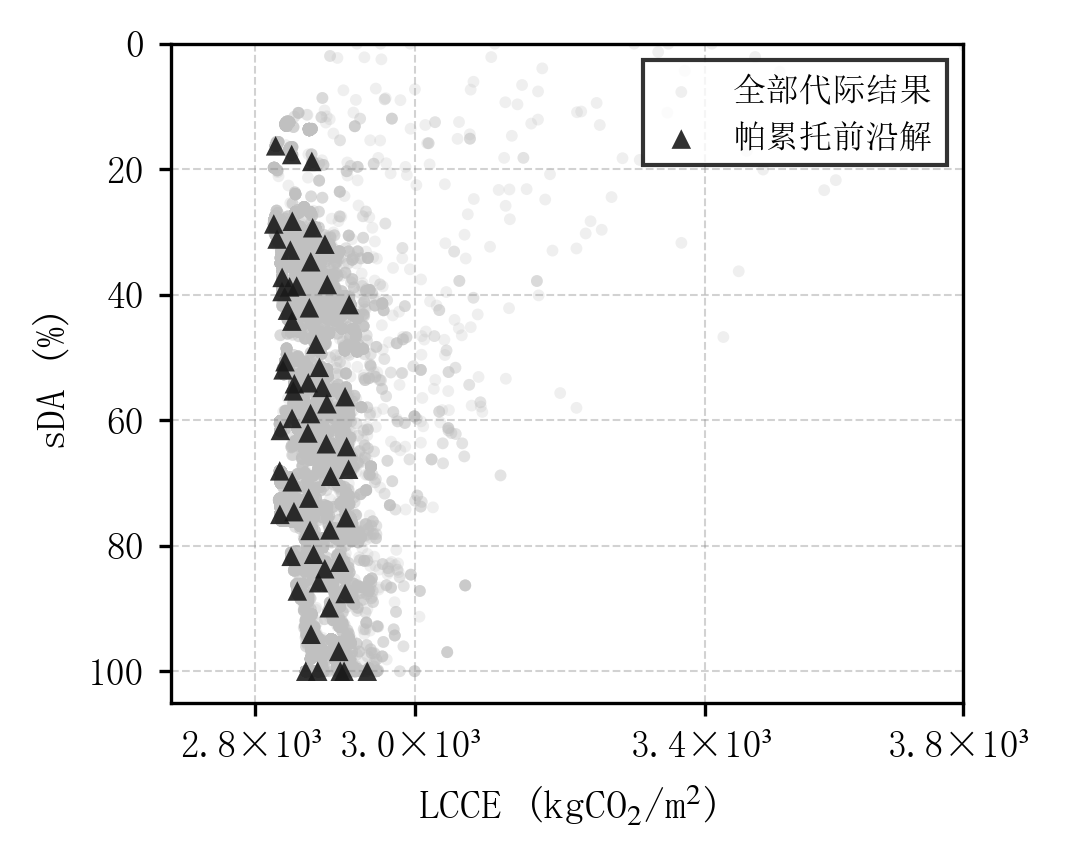

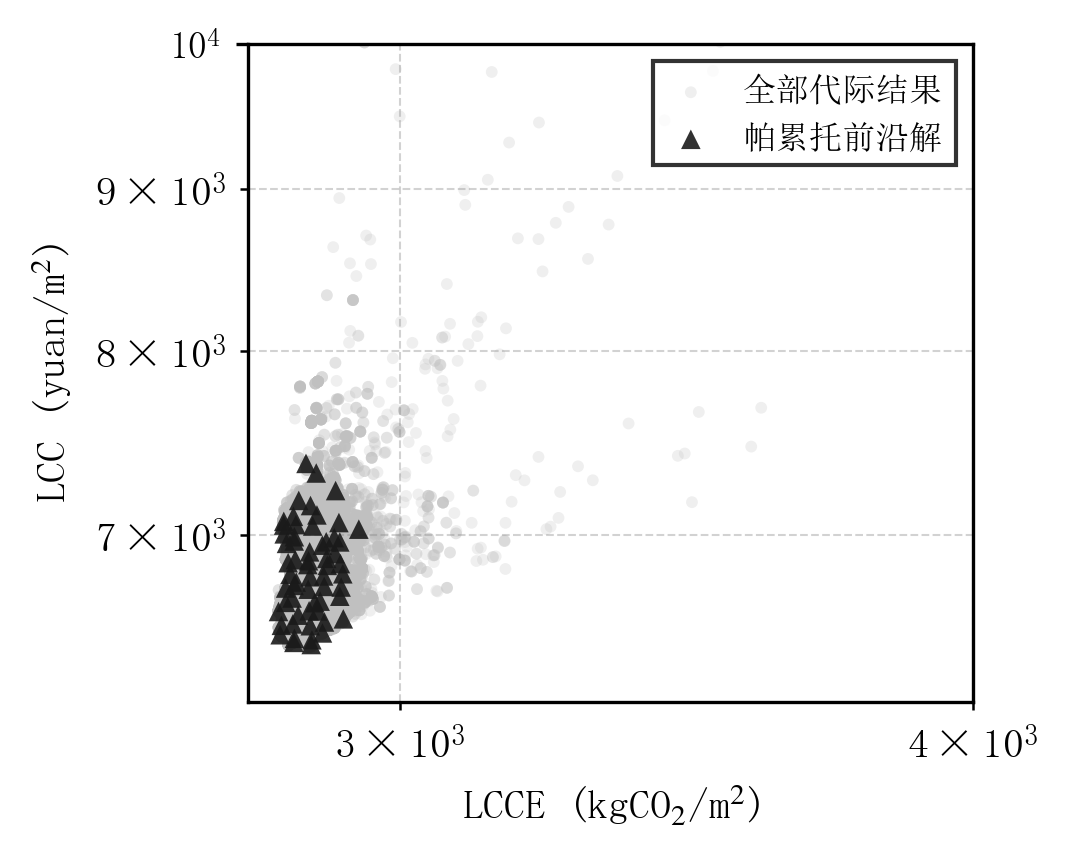

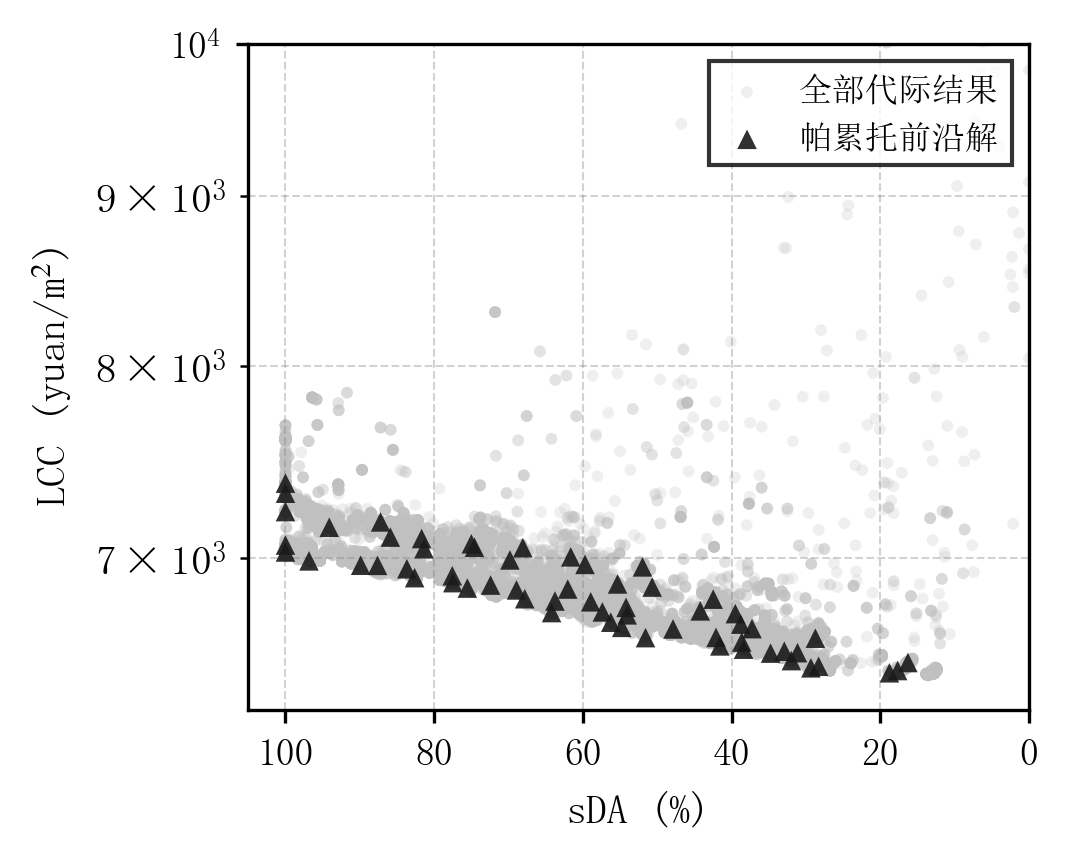

In [12]:
# ==================== Block 6: 二维帕累托前沿分布图（图1稀疏刻度修正，图2图3不变）====================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter

# 显式注册宋体
font_path = r'C:\Windows\Fonts\simsun.ttc'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'stix'

# 提取全部代际目标值
all_F = np.vstack([gen.pop.get("F") for gen in res.history])
pareto_F = res.F

lcce_all = all_F[:, 0]
sda_all  = -all_F[:, 1]    # 还原为正的 sDA (%)
lcc_all  = all_F[:, 2]

lcce_pf = pareto_F[:, 0]
sda_pf  = -pareto_F[:, 1]   # 还原为正的 sDA (%)
lcc_pf  = pareto_F[:, 2]

# 统一图面参数
ALL_COLOR   = '#C0C0C0'
ALL_MARKER  = 'o'
ALL_SIZE    = 8
ALL_ALPHA   = 0.25

PF_COLOR    = '#1a1a1a'
PF_MARKER   = '^'
PF_SIZE     = 22
PF_ALPHA    = 0.9
GRID_ALPHA  = 0.35

# 【图1专用】窄范围对数轴刻度：固定 1 位小数 ×10³
def log_formatter_fixed(x, pos):
    if x == 0:
        return '0'
    if 1000 <= x < 10000:
        return f'{x/1000:.1f}×10³'
    elif x >= 10000:
        return f'{x/1000:.0f}×10³'
    return f'{x:.0f}'

# ---------- 图 1: LCCE vs sDA（x轴刻度强制固定） ----------
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

ax.scatter(lcce_all, sda_all, c=ALL_COLOR, marker=ALL_MARKER, s=ALL_SIZE,
           alpha=ALL_ALPHA, edgecolors='none', label='全部代际结果', zorder=1)
ax.scatter(lcce_pf, sda_pf, c=PF_COLOR, marker=PF_MARKER, s=PF_SIZE,
           alpha=PF_ALPHA, edgecolors='none', label='帕累托前沿解', zorder=3)

ax.set_xscale('log')
ax.set_xlim(2700, 3800)

# 【关键修正】对数轴强制固定：FixedLocator + FixedFormatter（直接绑定字符串，不经过函数）
import matplotlib.ticker as mticker
ax.xaxis.set_major_locator(mticker.FixedLocator([2800, 3000, 3400, 3800]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(
    ['2.8×10³', '3.0×10³', '3.4×10³', '3.8×10³']
))
ax.minorticks_off()  # 关闭对数轴自动 minor ticks，避免任何视觉干扰

ax.set_ylim(0, 105)
ax.invert_yaxis()

ax.set_xlabel('LCCE (kgCO$_2$/m$^{2}$)', fontsize=10, labelpad=5)
ax.set_ylabel('sDA (%)', fontsize=10, labelpad=5)

ax.grid(True, linestyle='--', alpha=GRID_ALPHA, color='gray', linewidth=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.tick_params(axis='both', which='major', labelsize=9, length=3, width=0.8)

legend = ax.legend(loc='upper right', frameon=True, fancybox=False,
                   edgecolor='black', fontsize=8, handlelength=1.5)
plt.tight_layout(pad=0.5)
plt.savefig('pareto_lcce_sda_grayshape.png', dpi=600, bbox_inches='tight')
plt.show()

# ---------- 图 2: LCCE vs LCC（保持原样：双轴对数，自动刻度） ----------
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

ax.scatter(lcce_all, lcc_all, c=ALL_COLOR, marker=ALL_MARKER, s=ALL_SIZE,
           alpha=ALL_ALPHA, edgecolors='none', label='全部代际结果', zorder=1)
ax.scatter(lcce_pf, lcc_pf, c=PF_COLOR, marker=PF_MARKER, s=PF_SIZE,
           alpha=PF_ALPHA, edgecolors='none', label='帕累托前沿解', zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2780, 4000)
ax.set_ylim(6200, 10000)

# 图2保持自动对数刻度，不手动干预
ax.set_xlabel('LCCE (kgCO$_2$/m$^{2}$)', fontsize=10, labelpad=5)
ax.set_ylabel('LCC (yuan/m$^{2}$)', fontsize=10, labelpad=5)

ax.grid(True, linestyle='--', alpha=GRID_ALPHA, color='gray', linewidth=0.5, which='both')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.tick_params(axis='both', which='major', labelsize=9, length=3, width=0.8)

legend = ax.legend(loc='upper right', frameon=True, fancybox=False,
                   edgecolor='black', fontsize=8, handlelength=1.5)
plt.tight_layout(pad=0.5)
plt.savefig('pareto_lcce_lcc_grayshape.png', dpi=600, bbox_inches='tight')
plt.show()

# ---------- 图 3: sDA vs LCC（保持原样：y轴对数，自动刻度） ----------
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

ax.scatter(sda_all, lcc_all, c=ALL_COLOR, marker=ALL_MARKER, s=ALL_SIZE,
           alpha=ALL_ALPHA, edgecolors='none', label='全部代际结果', zorder=1)
ax.scatter(sda_pf, lcc_pf, c=PF_COLOR, marker=PF_MARKER, s=PF_SIZE,
           alpha=PF_ALPHA, edgecolors='none', label='帕累托前沿解', zorder=3)

ax.set_xlim(105, 0)
ax.set_ylim(6300, 10000)
ax.set_yscale('log')

# 图3保持自动对数刻度，不手动干预
ax.set_xlabel('sDA (%)', fontsize=10, labelpad=5)
ax.set_ylabel('LCC (yuan/m$^{2}$)', fontsize=10, labelpad=5)

ax.grid(True, linestyle='--', alpha=GRID_ALPHA, color='gray', linewidth=0.5, which='both')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')
ax.tick_params(axis='both', which='major', labelsize=9, length=3, width=0.8)

legend = ax.legend(loc='upper right', frameon=True, fancybox=False,
                   edgecolor='black', fontsize=8, handlelength=1.5)
plt.tight_layout(pad=0.5)
plt.savefig('pareto_sda_lcc_grayshape.png', dpi=600, bbox_inches='tight')
plt.show()

In [4]:
# ==================== 乌托邦解计算（保持不变）====================
import numpy as np
import pandas as pd

# 1. 提取帕累托前沿并还原 sDA
pareto_X = res.X          # 参数矩阵 (n_nds, 10)
pareto_F = res.F          # 目标矩阵 (n_nds, 3)，注意 sDA 存储为负值

lcce = pareto_F[:, 0]                     # LCCE (kgCO2/m2)
sda  = -pareto_F[:, 1]                    # 还原为正的 sDA (%)
lcc  = pareto_F[:, 2]                     # LCC (yuan/m2)

# 2. 三目标数值范围
print("=" * 60)
print("【帕累托前沿三目标数值范围】")
print(f"LCCE: {lcce.min():.2f} ~ {lcce.max():.2f} kgCO₂·m⁻²")
print(f"sDA:  {sda.min():.2f} ~ {sda.max():.2f} %")
print(f"LCC:  {lcc.min():.2f} ~ {lcc.max():.2f} yuan·m⁻²")
print("=" * 60)

# 3. 计算乌托邦点与距离
utopia_raw = np.array([lcce.min(), sda.max(), lcc.min()])

lcce_norm = (lcce - lcce.min()) / (lcce.max() - lcce.min() + 1e-9)
sda_norm  = (sda - sda.min()) / (sda.max() - sda.min() + 1e-9)
lcc_norm  = (lcc - lcc.min()) / (lcc.max() - lcc.min() + 1e-9)

pareto_norm = np.column_stack([lcce_norm, sda_norm, lcc_norm])
utopia_norm = np.array([0.0, 1.0, 0.0])

distances = np.linalg.norm(pareto_norm - utopia_norm, axis=1)

# 4. 取前十名乌托邦解
top10_idx = np.argsort(distances)[:10]

param_names = ['hor_depth', 'type', 'mat', 'int', 'hori_rot',
               'ver_rot', 'depth', 'distance', 'wwr', 'win']
obj_names   = ['LCCE', 'sDA', 'LCC']

top10_params_raw = pareto_X[top10_idx]
top10_params_rounded = np.round(top10_params_raw, 1)
top10_params_rounded[:, [1, 2, 9]] = np.round(top10_params_rounded[:, [1, 2, 9]]).astype(int)

df_top10 = pd.DataFrame(top10_params_rounded, columns=param_names)
df_top10.insert(0, 'rank', np.arange(1, 11))
df_top10['LCCE'] = np.round(lcce[top10_idx], 2)
df_top10['sDA']  = np.round(sda[top10_idx], 2)
df_top10['LCC']  = np.round(lcc[top10_idx], 2)
df_top10['distance_to_utopia'] = np.round(distances[top10_idx], 6)

cols = ['rank'] + obj_names + ['distance_to_utopia'] + param_names
df_top10 = df_top10[cols]

print("\\n【前十名乌托邦解（距离乌托邦点最近）】")
print(df_top10.to_string(index=False))

csv_filename = 's_top10_utopia_solutions.csv'
df_top10.to_csv(csv_filename, index=False, float_format='%.4f')
print(f"\\n✓ 结果已保存至 {csv_filename}")

print(f"\\n乌托邦点参考值：LCCE={utopia_raw[0]:.2f}, sDA={utopia_raw[1]:.2f}, LCC={utopia_raw[2]:.2f}")

【帕累托前沿三目标数值范围】
LCCE: 2822.52 ~ 2938.67 kgCO₂·m⁻²
sDA:  16.28 ~ 100.00 %
LCC:  6466.27 ~ 7374.83 yuan·m⁻²
\n【前十名乌托邦解（距离乌托邦点最近）】
 rank    LCCE   sDA     LCC  distance_to_utopia  hor_depth  type  mat  int  hori_rot  ver_rot  depth  distance  wwr  win
    1 2865.37 72.41 6871.70            0.666195        5.5   2.0  1.0  5.8       4.8     -8.8    1.0       1.7  6.5  1.0
    2 2847.71 54.19 6766.24            0.674866        5.2   2.0  1.0  8.9       7.5     -8.2    1.0       1.0  4.0  4.0
    3 2867.01 77.56 6916.18            0.681013        5.9   2.0  1.0  5.6       0.1     -8.5    1.0       1.6  7.0  1.0
    4 2845.09 69.81 6992.54            0.709452        5.1   2.0  1.0  5.9       4.3     -5.2    1.0       1.4  6.1  4.0
    5 2864.36 62.03 6852.78            0.718627        5.1   2.0  1.0  9.0       4.3     -4.3    1.0       1.4  4.5  4.0
    6 2864.91 54.04 6731.31            0.720895        5.8   2.0  1.0  9.0       7.8     -4.4    1.0       1.4  3.4  4.0
    7 2867.63 58.95 6792.3

In [9]:
# ==================== 保存 npz（保持不变）====================
import numpy as np

np.savez('nsga3_res_data.npz', X=res.X, F=res.F)
print(f"✓ Pareto 前沿已保存: X={res.X.shape}, F={res.F.shape}")

try:
    history_F = np.vstack([gen.pop.get("F") for gen in res.history])
    np.savez('nsga3_history.npz', all_F=history_F, pareto_F=res.F)
    print(f"✓ 历史数据已保存: all_F={history_F.shape}")
except Exception as e:
    print(f"⚠️ 历史数据保存跳过: {e}")

✓ Pareto 前沿已保存: X=(60, 10), F=(60, 3)
✓ 历史数据已保存: all_F=(20000, 3)


In [10]:
# ==================== 乌托邦解筛选（基于图片公式4-1/4-2）====================
import pandas as pd

# 1. 提取帕累托前沿并还原sDA
pareto_F = res.F.copy()
pareto_F[:, 1] = -pareto_F[:, 1]  # 还原为正值

pareto_X = res.X
n_solutions = len(pareto_F)

# 2. 提取三目标
lcce = pareto_F[:, 0]
sda = pareto_F[:, 1]
lcc = pareto_F[:, 2]

# 3. 各目标最优值（注意优化方向）
lcce_best = lcce.min()   # 最小化
sda_best = sda.max()     # 最大化
lcc_best = lcc.min()     # 最小化

# 4. 防止除零
epsilon = 1e-12
lcce_best = max(lcce_best, epsilon)
sda_best = max(sda_best, epsilon)
lcc_best = max(lcc_best, epsilon)

# 5. 公式(4-1): 相对最优值的偏差距离
d_lcce = (lcce - lcce_best) / lcce_best
d_sda = (sda_best - sda) / sda_best
d_lcc = (lcc - lcc_best) / lcc_best

distances = np.sqrt(d_lcce**2 + d_sda**2 + d_lcc**2)

# 6. 公式(4-2): 取距离最小的前10个
top_n = min(10, n_solutions)
top_indices = np.argsort(distances)[:top_n]

# 7. 参数名
param_names = ['hor_depth', 'type', 'mat', 'int', 'hori_rot',
               'ver_rot', 'depth', 'distance', 'wwr', 'win']

# 8. 构建结果表
df_top10 = pd.DataFrame({
    'rank': np.arange(1, top_n+1),
    'LCCE': np.round(lcce[top_indices], 2),
    'sDA': np.round(sda[top_indices], 2),
    'LCC': np.round(lcc[top_indices], 2),
    'distance': np.round(distances[top_indices], 6)
})

# 9. 添加参数（离散变量取整，连续变量保留1位小数）
for i, name in enumerate(param_names):
    vals = pareto_X[top_indices, i]
    if name in ['type', 'mat', 'win']:
        vals = np.round(vals).astype(int)
    else:
        vals = np.round(vals, 1)
    df_top10[name] = vals

# 10. 输出与保存
print("\n【前十名乌托邦解】")
print(df_top10.to_string(index=False))

csv_name = 'top10_utopia_solutions.csv'
df_top10.to_csv(csv_name, index=False, float_format='%.4f')
print(f"\n✓ 结果已保存至 {csv_name}")

# 11. 验证：乌托邦点参考值
print(f"\n乌托邦点参考值：LCCE={lcce_best:.2f}, sDA={sda_best:.2f}, LCC={lcc_best:.2f}")
print(f"帕累托解总数：{n_solutions}，选取前{top_n}名")


【前十名乌托邦解】
 rank    LCCE    sDA     LCC  distance  hor_depth  type  mat  int  hori_rot  ver_rot  depth  wwr  win
    1 2902.71  96.83 6987.93       1.8        5.2     2    1  6.0       4.1     -1.6    1.0  7.0    1
    2 2938.67 100.00 7031.13       3.0        5.1     2    3  9.0       3.0      0.6    1.0  7.0    1
    3 2909.43 100.00 7064.87       3.1        5.1     2    1  5.9       5.0      0.7    1.0  7.8    1
    4 2904.62 100.00 7230.82       1.6        5.9     1    1  6.0       0.0     -2.8    1.0  7.0    1
    5 2868.22  94.11 7152.66       3.0        5.7     2    1  5.9       0.4     -0.5    1.0  7.0    4
    6 2890.95  89.89 6966.94       1.7        5.2     2    1  5.9       4.2     -3.0    1.0  7.1    1
    7 2876.51 100.00 7323.68       1.8        5.7     1    1  8.9       0.6     -8.3    1.0  7.0    4
    8 2861.72 100.00 7374.83       1.7        5.9     1    1  5.9       0.6     -2.8    1.0  7.0    4
    9 2910.71  87.62 6966.29       1.7        5.6     2    1  9.0      